# Hugging Face Tutorial



## 0. Pretraining and Fine-tuning

**Pretraining(사전학습)**
- 모델을 대규모 데이터셋을 활용해서 학습시키는 과정
- 비지도학습을 통해 특정 태스크에 초점을 맞추지 않고, 언어의 일반적인 패턴, 구조, 문법, 지식 등을 학습하는 과정

**Fine-tuning(추가학습)**
- 사전학습된 모델을 특정 데이터셋에서 추가로 학습시키는 과정
- 모델이 일반적인 지식을 특정 작업에 맞게 적용할 수 있도록 함



## 1. HuggingFace (https://huggingface.co)

### Hugging Face란?
자연어 처리(NLP)와 인공지능(AI) 연구 분야에서 널리 사용되는 플랫폼
 특히, `transformers` 라이브러리를 통해 다양한 사전학습된 모델과 데이터셋을 제공

### Hugging Face의 주요 특징
1. **사전학습된 모델 제공**: 다양한 사전학습된 모델을 불러와 추가학습(fine-tuning)하거나 바로 사용이 가능
2. **다양한 태스크 지원**: 텍스트 분류, 질의응답, 텍스트 생성, 번역, 감정 분석 등 다양한 NLP 태스크를 지원
3. **오픈소스 커뮤니티**: 다양한 모델과 데이터셋이 커뮤니티에 의해 공유

---

## Transformers 라이브러리에서 사용하는 주요 클래스

### 1. `AutoModel`
- Hugging Face에서 다양한 모델을 쉽게 불러오기 위한 자동화 클래스로,  모델 이름만 입력하면 적절한 모델을 자동으로 불러옴.
- **주요 모델**:
  - `AutoModel`: 일반적인 사전학습 모델
  - `AutoModelForSequenceClassification`: 텍스트 분류를 위한 모델
  - `AutoModelForTokenClassification`: 네임드 엔티티 인식(NER) 등을 위한 모델
  - `AutoModelForCausalLM`: 텍스트 생성(언어 모델링)을 위한 모델
  - `AutoModelForMaskedLM`: BERT와 같은 Masked Language Model(Masked LM) 모델

### 2. `AutoTokenizer`
- 입력 텍스트를 모델이 이해할 수 있는 형태인 토큰으로 변환하는 토크나이저를 자동으로 불러옴
- **기능**:
  - 텍스트 토큰화: 텍스트를 모델이 이해할 수 있는 형태로 변환
  - 디코딩: 모델의 예측 결과를 다시 텍스트로 변환
  - 패딩 및 자르기: 입력 길이를 모델에 맞게 조정


---

## Transformers 라이브러리에서 사용되는 기타 주요 클래스

### 모델 관련 클래스
- `AutoModel`: 모든 종류의 사전학습된 모델을 자동으로 불러옴
- `AutoModelForSequenceClassification`: 텍스트 분류를 위한 모델
- `AutoModelForTokenClassification`: 네임드 엔티티 인식을 위한 모델
- `AutoModelForCausalLM`: 텍스트 생성(언어 모델링)을 위한 모델
- `AutoModelForMaskedLM`: Masked Language Modeling을 위한 모델
- `AutoModelForQuestionAnswering`: 질의응답 태스크를 위한 모델

### 토크나이저 관련 클래스
- `AutoTokenizer`: 특정 모델에 맞는 토크나이저를 자동으로 불러옴
- `BertTokenizer`: BERT 모델에 맞춘 토크나이저
- `GPT2Tokenizer`: GPT-2 모델에 맞춘 토크나이저
- `RobertaTokenizer`: RoBERTa 모델에 맞춘 토크나이저

### 추가 학습 및 평가 관련 클래스
- `Trainer`: 추가학습과 평가를 쉽게 수행할 수 있는 고수준의 인터페이스
- `TrainingArguments`: Trainer와 함께 사용하는 설정 클래스. 학습 속성(학습률, 배치 크기 등)을 설정



In [1]:
!pip install transformers torch

## 2. Loading a Pretrained GPT-2 Model for Text Generation

- Generative Pretrained Transformer (GPT)
- Next token prediction: 주어진 문맥에서 다음에 올 단어를 예측하는 방식으로 학습
- Autoregressive: 텍스트를 왼쪽에서 오른쪽으로 읽으며 이전 단어들을 기반으로 다음 단어를 생성 --> 문장을 자연스럽게 확장

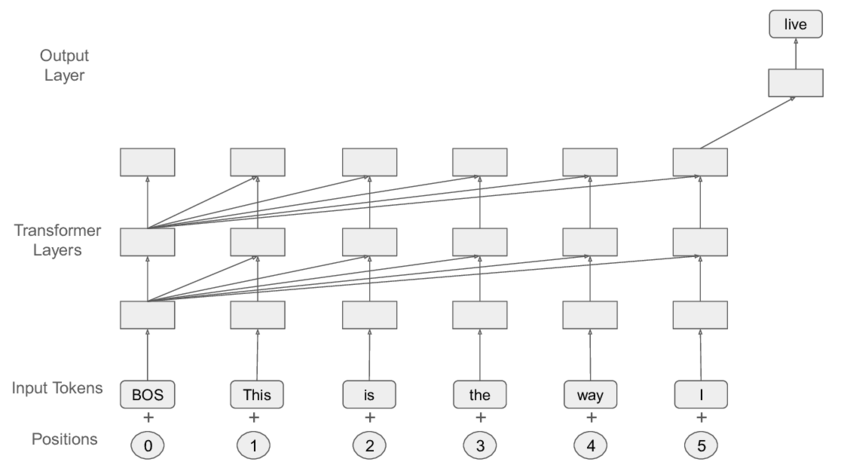

In [8]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2")
# Example input text
input_text = 'Once upon a time in a land far, far away'
input_ids = tokenizer.encode(input_text, return_tensors='pt')

# Generate text
output = model.generate(input_ids, max_length=50)

# Decode and display the generated text
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print('Generated Text: ', generated_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generated Text:  Once upon a time in a land far, far away, the world was a land of the dead, where the dead were buried, and the dead were buried. The dead were buried in the land of the dead, and the dead were buried in


In [9]:

# Load the GPT-2 model and tokenizer
model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2")

# Example input text
input_text = 'Once upon a time in a land far, far away'
input_ids = tokenizer.encode(input_text, return_tensors='pt')

# Generate text with adjusted parameters
output = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    temperature=0.8,        # 샘플링 다양성을 증가시킴
    top_k=50,                # 상위 50개의 단어만 고려
    top_p=0.9,               # 누적 확률 90%까지 단어 선택
    repetition_penalty=1.2   # 반복 방지를 위한 패널티
)

# Decode and display the generated text
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print('Generated Text: ', generated_text)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generated Text:  Once upon a time in a land far, far away from the stars and planets we live within these cosmic rays.
The Universe has two fundamental particles that are called protons (pronounced "pok-tz"), which have formed inside us for


## 3. Using BERT Models for Different NLP Tasks
- BERT 모델은, next token prediction보다는, masked language model 로 학습된 모델
- 입력 문장 내에서 일부 단어를 마스킹 한 후, 그 마스킹된 단어를 예측하도록 학습됨
- 문장 전체의 문맥을 이해하며 빈칸에 해당하는 단어를 채우는 데 뛰어난 성능을 보임
- 문장을 한방향으로만 텍스트를 처리하는 것이 아니라, 앞뒤 문맥을 동시에 고려할 수 있음

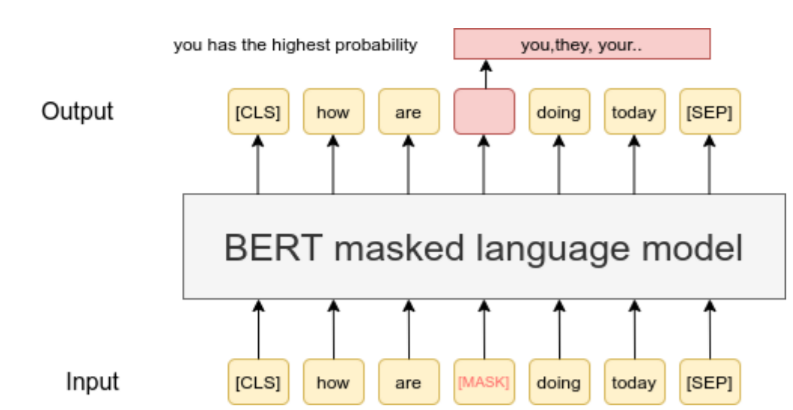

In [11]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

# BERT Base 모델과 토크나이저를 직접 로드
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Masked Language Modeling을 위한 BERT 모델 로드
model = AutoModelForMaskedLM.from_pretrained(model_name)

# 예제 문장 - 일부 단어를 마스킹함 ([MASK] 토큰으로 대체)
text ="To be or not to be, [MASK] is question."

# 입력 텍스트를 토큰화
inputs = tokenizer(text, return_tensors="pt")

# 모델을 사용해 마스킹된 토큰 예측 수행
with torch.no_grad():
    outputs = model(**inputs)

# 마스킹된 위치에 대한 예측 로짓(logits)을 가져옴
mask_token_index = torch.where(inputs['input_ids'] == tokenizer.mask_token_id)[1]
logits = outputs.logits

# 각 마스킹된 토큰에 대해 가장 높은 확률의 단어 예측
predicted_token_id = torch.argmax(logits[0, mask_token_index, :], dim=-1)
predicted_token = tokenizer.decode(predicted_token_id)

# 결과 출력
print(f'Original Text: {text}')
print(f'Predicted Token: {predicted_token}')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Original Text: To be or not to be, [MASK] is question.
Predicted Token: there


In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# BERT Base 모델과 토크나이저 로드
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)  # classification model을 위한 함수

# 감정 분석을 위한 입력 텍스트
text = "I love LG!"

# 입력 텍스트를 토큰화
inputs = tokenizer(text, return_tensors="pt")

# 모델을 사용해 예측 수행
outputs = model(**inputs)

# 출력 로짓(logits)을 소프트맥스 함수로 확률로 변환
probabilities = F.softmax(outputs.logits, dim=1)

# 결과 확인
labels = ['Negative', 'Positive']
predicted_label = labels[torch.argmax(probabilities)]
confidence = torch.max(probabilities).item()

print(f'Sentiment Analysis Result: {predicted_label} (Confidence: {confidence:.2f})')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Sentiment Analysis Result: Positive (Confidence: 0.60)


## 4. Fine-tuning a Small Pretrained Model on Custom Data

1. GPT-2 를 한국어 데이터로 finetuning
2. BERT를 sentimental classification 으로 finetuning

In [18]:
!pip install datasets


In [28]:
# 데이터셋 로드 (wikitext-2 데이터셋 사용)
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1')
# 데이터셋의 구성 확인
print("Dataset Structure:")
print(dataset)

# 각 split(train, validation, test)의 데이터 개수 확인
print("\nNumber of samples in each split:")
for split in dataset:
    print(f"{split.capitalize()} samples: {len(dataset[split])}")


Dataset Structure:
DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

Number of samples in each split:
Test samples: 4358
Train samples: 36718
Validation samples: 3760


In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from datasets import load_dataset
import torch

# GPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# GPT-2 모델과 토크나이저 로드
model_name = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# 텍스트 토큰화 함수 정의
def tokenize_function(examples):
    # 입력 텍스트를 토큰화하고 labels 추가
    encoding = tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)
    encoding['labels'] = encoding['input_ids'].copy()  # labels에 input_ids를 복사하여 설정
    return encoding
# 데이터셋 토큰화
tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# 학습 및 검증 데이터셋 설정
train_dataset = tokenized_datasets['train'].shuffle().select(range(2000))  # 데이터 양 조절 가능
eval_dataset = tokenized_datasets['validation'].shuffle().select(range(500))  # 검증 데이터셋 선택

# 추가학습 설정
training_args = TrainingArguments(
    output_dir='./results-gpt2-finetuning',  # 모델의 체크포인트와 학습 결과가 저장될 디렉토리
    num_train_epochs=3,  # 데이터셋을 학습하는 총 Epoch 수 (데이터셋을 3번 반복 학습)
    per_device_train_batch_size=8,  # 각 GPU/CPU 장치당 학습에 사용되는 배치 크기
    evaluation_strategy="epoch",  # 매 epoch이 끝날 때마다 평가를 수행
    logging_dir='./logs',  # 학습 중 로그가 저장될 디렉토리 (TensorBoard 등에서 사용 가능)
    save_total_limit=2,  # 저장할 체크포인트의 최대 개수 (초과 시 가장 오래된 체크포인트 삭제)
    save_steps=500,  # 매 500 스텝마다 모델 체크포인트를 저장
    report_to="none"  # WandB 및 기타 로깅 도구 비활성화
)

# Trainer 초기화 및 학습
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

# 추가학습 수행
trainer.train()

# 추가학습 후 텍스트 생성 예제
input_text = "Once upon a time in a land far, far away"
input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

# 텍스트 생성
output = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    temperature=0.8,
    top_k=50,
    top_p=0.9,
    repetition_penalty=1.2
)

# 생성된 텍스트 디코딩 및 출력
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print('Generated Text After Fine-Tuning: ', generated_text)


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,1.387802
2,1.345300,1.394673
3,1.345300,1.403181


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generated Text After Fine-Tuning:  Once upon a time in a land far, far away, the peoples of Asia Minor lived side byside. There were no religious beliefs or practices ; it was an integrated culture that blended traditional and contemporary religions to create modern forms from scratch – one community


In [29]:
# IMDb 감정 분석 데이터셋 로드
dataset = load_dataset('imdb')

# 데이터셋의 구조 확인
print("Dataset Structure:")
print(dataset)

# 각 split(train, test)의 데이터 개수 확인
print("\nNumber of samples in each split:")
for split in dataset:
    print(f"{split.capitalize()} samples: {len(dataset[split])}")

# 데이터셋의 첫 번째 샘플 확인 (학습 데이터셋)
print("\nExample from the training dataset:")
print(dataset['train'][0])

# 데이터셋의 첫 번째 샘플 확인 (테스트 데이터셋)
print("\nExample from the test dataset:")
print(dataset['test'][0]['text'])
print(dataset['test'][0]['label'])

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Number of samples in each split:
Train samples: 25000
Test samples: 25000
Unsupervised samples: 50000

Example from the training dataset:
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on

In [33]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import torch
import torch.nn.functional as F

# GPU가 사용 가능한지 확인하고, 장치를 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# BERT Base 모델과 토크나이저 로드
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)  # 모델을 GPU로 이동

# 텍스트 토큰화 함수 정의
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

# 데이터셋 토큰화
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 학습 및 검증 데이터셋 설정
train_dataset = tokenized_datasets['train'].shuffle().select(range(2000))  # 데이터 양 조절 가능
eval_dataset = tokenized_datasets['test'].shuffle().select(range(500))  # 검증 데이터셋 선택

# 추가학습 설정
training_args = TrainingArguments(
    output_dir='./results-sentiment-classification',  # 모델의 체크포인트와 결과가 저장될 디렉토리
    num_train_epochs=3,  # 전체 데이터셋을 학습하는 횟수 (Epoch 수)
    per_device_train_batch_size=8,  # 각 GPU/CPU 장치당 학습에 사용되는 배치 크기
    evaluation_strategy="epoch",  # 매 epoch이 끝날 때마다 모델 평가 수행
    logging_dir='./logs',  # 학습 중 로그가 저장될 디렉토리 (TensorBoard 등에서 사용)
    save_total_limit=2,  # 저장할 체크포인트의 최대 개수 (초과 시 가장 오래된 체크포인트 삭제)
    save_steps=500,  # 학습 중 일정 step마다 모델 체크포인트를 저장
    report_to="none"  # 로깅 툴 비활성화 (예: WandB나 TensorBoard를 사용하지 않음)
)

# Trainer 초기화 및 학습
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

# 추가학습 수행
trainer.train()

# 추가학습 후 감정 분석 예제
text = "I love LG!"
inputs = tokenizer(text, return_tensors="pt").to(device)  # 입력 텐서를 모델이 있는 장치로 이동

# Fine-tuning된 모델로 예측 수행
outputs = model(**inputs)

# 출력 로짓(logits)을 소프트맥스 함수로 확률로 변환
probabilities = F.softmax(outputs.logits, dim=1)

# 결과 확인
labels = ['Negative', 'Positive']
predicted_label = labels[torch.argmax(probabilities)]
confidence = torch.max(probabilities).item()

print(f'Sentiment Analysis Result After Fine-Tuning: {predicted_label} (Confidence: {confidence:.2f})')


/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,No log,0.409129
2,0.385700,0.578391
3,0.385700,0.723443


Sentiment Analysis Result After Fine-Tuning: Positive (Confidence: 1.00)
